# PU diagnostics v2 — does U actually contain hidden sockpuppets?

The 3-way feature means told us U-on-average looks like N. But hidden sockpuppets could still exist as a *minority* of U. This notebook answers the question rigorously.

**Two diagnostics:**

1. **P-vs-N classifier**: Train on the clean binary problem (P vs N), apply to U. The U-positive rate is an honest empirical α estimate.
2. **P-vs-U classifier with N as validation**: Train Elkan-Noto on P-vs-U, then measure how often it flags *N* as positive. Compare to U flagging rate to get a "U excess" — the real α.

Both should agree if the framing is right. If they wildly disagree, that itself is informative.


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# --- CONFIG ---
FEATURES_CSV = "./user_features_pu.csv"
SEEDS = 5
FOLDS = 5
# --------------

feats = pd.read_csv(FEATURES_CSV)
feature_cols = [c for c in feats.columns
                if c not in ('user_id','label_3way','is_sockpuppet','ip_checked')]
X = feats[feature_cols].to_numpy(dtype=np.float32)
labels = feats['label_3way'].values
user_ids = feats['user_id'].values

P_mask = labels == 'P'
N_mask = labels == 'N'
U_mask = labels == 'U'

print(f"Loaded: P={P_mask.sum()}, N={N_mask.sum()}, U={U_mask.sum()}, "
      f"features={X.shape[1]}")

Loaded: P=142, N=252, U=678, features=34


## Diagnostic 1: P-vs-N classifier, then probe U

Standard binary classification on the *clean* label subset. If burstiness/hour-entropy etc. truly separate sockpuppets from normal users, this classifier should hit decent F1. Then we apply it to U and count how many it flags.

The U-flagging rate ≈ empirical α (with classifier-error caveat).


In [2]:
def stratified_eval(X, y, n_seeds=5, n_folds=5, clf_factory=None):
    """Standard binary CV; returns mean/std F1, P, R, AUC."""
    if clf_factory is None:
        clf_factory = lambda seed: RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            random_state=seed, n_jobs=-1
        )

    metrics = []
    for seed in range(n_seeds):
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        fold_m = []
        for tr, te in skf.split(X, y):
            scaler = StandardScaler().fit(X[tr])
            clf = clf_factory(seed)
            clf.fit(scaler.transform(X[tr]), y[tr])
            scores = clf.predict_proba(scaler.transform(X[te]))[:, 1]
            y_pred = (scores >= 0.5).astype(int)
            fold_m.append({
                'f1': f1_score(y[te], y_pred, zero_division=0),
                'precision': precision_score(y[te], y_pred, zero_division=0),
                'recall': recall_score(y[te], y_pred, zero_division=0),
                'auc': roc_auc_score(y[te], scores) if len(set(y[te]))>1 else float('nan'),
            })
        metrics.append({k: np.mean([m[k] for m in fold_m]) for k in fold_m[0]})

    agg = {k: np.array([m[k] for m in metrics]) for k in metrics[0]}
    return {k: (float(v.mean()), float(v.std())) for k, v in agg.items()}


# Train P-vs-N
pn_mask = P_mask | N_mask
X_pn = X[pn_mask]
y_pn = P_mask[pn_mask].astype(int)   # 1 = P, 0 = N

print('=== Diagnostic 1: P-vs-N classifier (clean binary) ===\n')
pn_metrics = stratified_eval(X_pn, y_pn, n_seeds=SEEDS, n_folds=FOLDS)
for k, (mean, std) in pn_metrics.items():
    print(f'  {k:10s} {mean:.3f} ± {std:.3f}')

# Train final classifier on ALL P+N, score U
scaler_pn = StandardScaler().fit(X_pn)
clf_pn = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                 random_state=0, n_jobs=-1)
clf_pn.fit(scaler_pn.transform(X_pn), y_pn)

u_scores_d1 = clf_pn.predict_proba(scaler_pn.transform(X[U_mask]))[:, 1]
u_flag_rate_d1 = (u_scores_d1 >= 0.5).mean()
print(f'\n  U-flagging rate (P-vs-N classifier applied to U):')
print(f'    {u_flag_rate_d1*100:.1f}% of U flagged as positive')
print(f'    → empirical alpha estimate ≈ {u_flag_rate_d1*100:.1f}%')

=== Diagnostic 1: P-vs-N classifier (clean binary) ===

  f1         0.441 ± 0.020
  precision  0.531 ± 0.035
  recall     0.382 ± 0.013
  auc        0.646 ± 0.013

  U-flagging rate (P-vs-N classifier applied to U):
    16.5% of U flagged as positive
    → empirical alpha estimate ≈ 16.5%


## Diagnostic 2: P-vs-U Elkan-Noto, then validate on N

Now train Elkan-Noto on P-vs-U (the standard PU setup) and probe how often it flags *N* users — confirmed clean — as positive. That's a real false-positive rate.

The "U excess" = U-flag rate − N-flag rate. If excess is meaningfully positive, U contains hidden positives. If excess ≈ 0, U is just like N and there are no hidden sockpuppets to find.


In [3]:
def elkan_noto_full_data(X, P_mask, U_mask, n_seeds=5):
    """Train Elkan-Noto on P-vs-U, return scores for all rows."""
    all_scores = np.zeros((n_seeds, X.shape[0]), dtype=float)

    p_idx = np.where(P_mask)[0]
    u_idx = np.where(U_mask)[0]

    for seed in range(n_seeds):
        rng = np.random.RandomState(seed)
        p_shuffled = p_idx.copy()
        rng.shuffle(p_shuffled)
        n_hold = max(5, len(p_idx) // 4)
        p_hold = p_shuffled[:n_hold]
        p_train = p_shuffled[n_hold:]

        train_idx = np.concatenate([p_train, u_idx])
        y_train = np.zeros(len(train_idx), dtype=int)
        y_train[:len(p_train)] = 1

        scaler = StandardScaler().fit(X[train_idx])
        clf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=seed)
        clf.fit(scaler.transform(X[train_idx]), y_train)

        c = max(float(np.mean(clf.predict_proba(scaler.transform(X[p_hold]))[:,1])), 1e-3)

        raw = clf.predict_proba(scaler.transform(X))[:, 1]
        corrected = np.clip(raw / c, 0.0, 1.0)
        all_scores[seed] = corrected

    return all_scores.mean(axis=0), all_scores.std(axis=0)


print('=== Diagnostic 2: P-vs-U Elkan-Noto, N as validation ===\n')
en_scores, en_stds = elkan_noto_full_data(X, P_mask, U_mask, n_seeds=SEEDS)

p_flag_rate = (en_scores[P_mask] >= 0.5).mean()
n_flag_rate = (en_scores[N_mask] >= 0.5).mean()
u_flag_rate_d2 = (en_scores[U_mask] >= 0.5).mean()

print(f'  Flag rate on P (training positives, sanity check): {p_flag_rate*100:.1f}%')
print(f'  Flag rate on N (confirmed clean — false positives): {n_flag_rate*100:.1f}%')
print(f'  Flag rate on U:                                     {u_flag_rate_d2*100:.1f}%')
print()
excess = u_flag_rate_d2 - n_flag_rate
print(f'  U excess over N: {excess*100:+.1f} percentage points')
print(f'  → If positive: U has more sockpuppet-like users than N')
print(f'  → If ~0:       U behaves like N (no hidden sockpuppets to find)')

=== Diagnostic 2: P-vs-U Elkan-Noto, N as validation ===

  Flag rate on P (training positives, sanity check): 91.5%
  Flag rate on N (confirmed clean — false positives): 64.3%
  Flag rate on U:                                     64.5%

  U excess over N: +0.2 percentage points
  → If positive: U has more sockpuppet-like users than N
  → If ~0:       U behaves like N (no hidden sockpuppets to find)


## Diagnostic 3: distribution comparison

Means hide the tails. Look at the score *distribution* on P, N, U. If U has a fat tail toward high scores that N doesn't have, that's evidence of hidden sockpuppets even if the mean is similar.


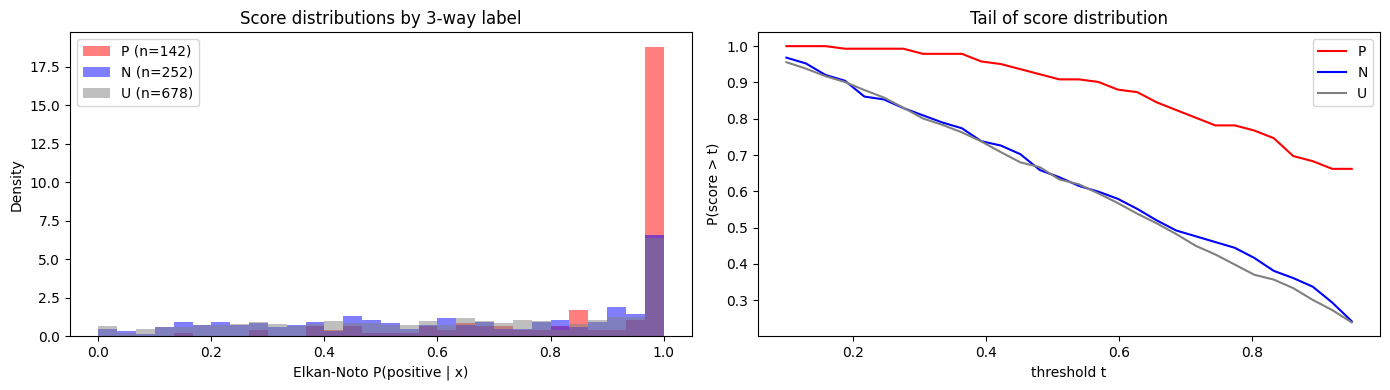

Quantitative tail comparison:
 threshold   P-rate   N-rate   U-rate      U-N
      0.30    97.9%    81.0%    81.0%    +0.0pp
      0.50    91.5%    64.3%    64.5%    +0.2pp
      0.70    81.7%    48.0%    46.6%    -1.4pp
      0.80    76.8%    41.7%    37.0%    -4.6pp
      0.90    67.6%    32.9%    29.5%    -3.4pp


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of scores
ax = axes[0]
bins = np.linspace(0, 1, 31)
ax.hist(en_scores[P_mask], bins=bins, alpha=0.5, label=f'P (n={P_mask.sum()})', color='red', density=True)
ax.hist(en_scores[N_mask], bins=bins, alpha=0.5, label=f'N (n={N_mask.sum()})', color='blue', density=True)
ax.hist(en_scores[U_mask], bins=bins, alpha=0.5, label=f'U (n={U_mask.sum()})', color='gray', density=True)
ax.set_xlabel('Elkan-Noto P(positive | x)')
ax.set_ylabel('Density')
ax.set_title('Score distributions by 3-way label')
ax.legend()

# Tail comparison: P(score > threshold) for each group
ax = axes[1]
thresholds = np.linspace(0.1, 0.95, 30)
p_above = [(en_scores[P_mask] > t).mean() for t in thresholds]
n_above = [(en_scores[N_mask] > t).mean() for t in thresholds]
u_above = [(en_scores[U_mask] > t).mean() for t in thresholds]
ax.plot(thresholds, p_above, label='P', color='red')
ax.plot(thresholds, n_above, label='N', color='blue')
ax.plot(thresholds, u_above, label='U', color='gray')
ax.set_xlabel('threshold t')
ax.set_ylabel('P(score > t)')
ax.set_title('Tail of score distribution')
ax.legend()
plt.tight_layout()
plt.show()

# Quantitative tail check: at various thresholds, how does U compare to N?
print('Quantitative tail comparison:')
print(f'{"threshold":>10} {"P-rate":>8} {"N-rate":>8} {"U-rate":>8} {"U-N":>8}')
for t in [0.3, 0.5, 0.7, 0.8, 0.9]:
    pr = (en_scores[P_mask] > t).mean()
    nr = (en_scores[N_mask] > t).mean()
    ur = (en_scores[U_mask] > t).mean()
    print(f'{t:>10.2f} {pr*100:>7.1f}% {nr*100:>7.1f}% {ur*100:>7.1f}% {(ur-nr)*100:>+7.1f}pp')

## Diagnostic 4: top U-flagged users — do they look like P?

For the highest-scoring U users, compare their feature profile to P, N, and the rest of U. If they look like P, those are the candidate hidden sockpuppets. If they look like other U, the classifier isn't really finding anything special.


In [5]:
u_indices = np.where(U_mask)[0]
u_score_per_idx = en_scores[U_mask]
top_k = 30
top_u_indices_local = np.argsort(-u_score_per_idx)[:top_k]
top_u_global_idx = u_indices[top_u_indices_local]
bottom_u_global_idx = u_indices[np.argsort(u_score_per_idx)[:top_k]]

print(f'Feature profile comparison (top-{top_k} U vs P vs N vs bottom-{top_k} U):\n')
profile = pd.DataFrame({
    'P_mean':        feats.iloc[np.where(P_mask)[0]][feature_cols].mean(),
    'N_mean':        feats.iloc[np.where(N_mask)[0]][feature_cols].mean(),
    'top_U_mean':    feats.iloc[top_u_global_idx][feature_cols].mean(),
    'bottom_U_mean': feats.iloc[bottom_u_global_idx][feature_cols].mean(),
}).round(2)
profile['top_U_matches_P_direction'] = (
    np.sign(profile['top_U_mean'] - profile['N_mean']) ==
    np.sign(profile['P_mean'] - profile['N_mean'])
)
print(profile.to_string())
print()
matches = profile['top_U_matches_P_direction'].sum()
print(f'Of {len(profile)} features, top-U behaves in the same direction as P (vs N) on {matches}.')
print(f'(Random chance would be ~{len(profile)/2:.0f}.)')
print()

# Save the top U candidates
top_u_users = feats.iloc[top_u_global_idx][['user_id'] + feature_cols].copy()
top_u_users['en_score'] = u_score_per_idx[top_u_indices_local]
top_u_users.to_csv('./top_u_candidates.csv', index=False)
print(f'Saved top-{top_k} U candidates to ./top_u_candidates.csv for manual inspection.')

Feature profile comparison (top-30 U vs P vs N vs bottom-30 U):

                              P_mean     N_mean  top_U_mean  bottom_U_mean  top_U_matches_P_direction
n_posts                        16.83      12.17        9.80          42.40                      False
n_threads                      11.98       9.37        6.63          24.60                      False
days_active                     8.79       6.83        5.73           3.80                      False
posts_per_thread                1.34       1.27        1.34           1.61                       True
posts_per_day                  13.03      16.53       10.00          25.46                       True
hour_entropy_bits               1.56       0.99        1.38           0.55                       True
dayofweek_entropy_bits          1.09       0.75        0.99           0.41                       True
interpost_mean_sec          87543.28  138223.32    59293.65       44088.27                       True
interpost_median_

## Decision tree based on outputs

After running all 4 diagnostics, look at:

| Signal | What it means | Thesis direction |
|---|---|---|
| **D1 high U-flag rate (~15%+) AND D2 large U-N excess (~10pp+) AND D4 top-U matches P on most features** | Hidden sockpuppets really do exist in U | Original PU thesis holds — develop methods to recover them |
| **D1 low U-flag rate (~5%) AND D2 small U-N excess (~2pp) AND D4 top-U looks like other U** | U is genuinely IP-unverifiable-but-clean | Pivot: thesis becomes "IP-based labeling is more complete than feared; U is mostly clean" — still publishable as a methodological finding |
| **D1 and D2 disagree significantly** | Something is wrong with the PU framing on this data | Thesis becomes "naive PU breaks on platform-collected sockpuppet data because labeling isn't SCAR" — that's a real methodology contribution |

**Run all 4 cells and paste the outputs.** Then we decide which direction to push.
